**Loading Required Libraries**

In [12]:
import numpy as np
import pandas as pd

**Loading Datasets**

In [13]:
df = pd.read_csv("play_tennis.csv")

y = df['play']
X = df.drop(['play', 'day'], axis=1)

**Entropy**

Entropy is an information theory metric that measures the impurity or uncertainty in a group of observations. It determines how a decision tree chooses to split data. 

Formula to calculate entropy:

$$H(S) = -\sum p_i \log_2(p_i)$$

The image below gives a better description of the purity of a set.

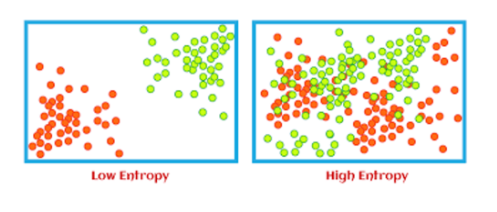

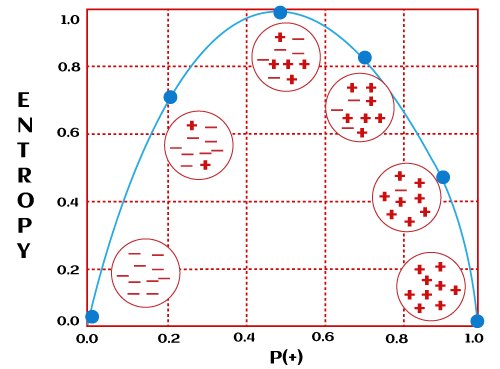

The range of values Entropy can have is between 0 to 1


Now Code to calculate the Entropy, and calculate the entropy of the loaded tennnis dataset.

In [14]:
#vectorization 
def entropy(y_data):
    probabilities = y_data.value_counts(normalize=True)
    result =  -np.sum(probabilities * np.log2(probabilities))
    return result

entropy(y)

0.9402859586706311

**Gini Impurity**

In [15]:
def gini_impurity(y_data):
    prob_list = y_data.value_counts(normalize=True)
    result = 1 - np.sum(prob_list ** 2)
    return result



gini_impurity(y)  

0.4591836734693877

**Difference between Entropy and Gini Impurity**

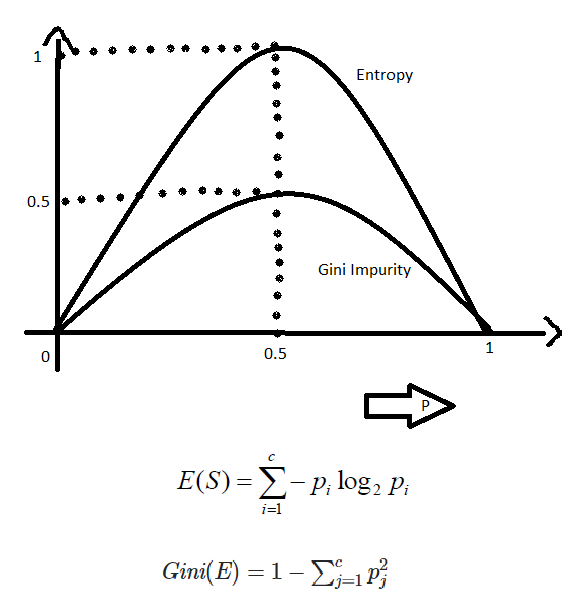




**Information gain**

Information gain is a measure used to determine which feature should be used to split the data at each internal node of the decision tree. It is calculated using entropy or Gini Impurity.

- More the Information gain, better the result.

$$ InformationGain(S, A) = E(S)-\sum_{Values(A)}^{}[avg weight]* E(A) $$

Where, S is Parent and A is children.

E is the entropy or gini impurity calculated. 

In [16]:
def information_gain(X_column, y):
    total_entropy = entropy(y)
    total_samples = len(y)
    
    wet_avg = []
    for value in X_column.unique():
        y_subset = y[X_column == value]
        prob = len(y_subset) / total_samples
        
        entropy_children = entropy(y_subset)
        wet_avg.append(prob * entropy_children)
        
    result =  total_entropy - sum(wet_avg)
    return result

In [17]:
ig = {}

for i in X.columns:
    ig[i] = information_gain(X[i], y)
    
print(ig)
print('_'*20)

maxi_gain = max(zip(ig.values(), ig.keys()))[1]
print("Highest Information Gain: "+maxi_gain)

{'outlook': 0.24674981977443933, 'temp': 0.02922256565895487, 'humidity': 0.15183550136234159, 'wind': 0.04812703040826949}
____________________
Highest Information Gain: outlook


"From the above data, taking outlook as a root node, the decision tree will be smart, iterating the same process again and again until the tree reaches a leaf node."